In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
# Load Dataset

df = pd.read_csv('Mall_Customers_Enhanced.csv')

In [7]:

df.head


<bound method NDFrame.head of      CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0             1    Male   19                  15                      39   
1             2    Male   21                  15                      81   
2             3  Female   20                  16                       6   
3             4  Female   23                  16                      77   
4             5  Female   31                  17                      40   
..          ...     ...  ...                 ...                     ...   
195         196  Female   35                 120                      79   
196         197  Female   45                 126                      28   
197         198    Male   32                 126                      74   
198         199    Male   32                 137                      18   
199         200    Male   30                 137                      83   

    Age Group  Estimated Savings (k$)  Credit Score  Loya

In [8]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   CustomerID              200 non-null    int64  
 1   Gender                  200 non-null    object 
 2   Age                     200 non-null    int64  
 3   Annual Income (k$)      200 non-null    int64  
 4   Spending Score (1-100)  200 non-null    int64  
 5   Age Group               196 non-null    object 
 6   Estimated Savings (k$)  200 non-null    float64
 7   Credit Score            200 non-null    int64  
 8   Loyalty Years           200 non-null    int64  
 9   Preferred Category      200 non-null    object 
dtypes: float64(1), int64(6), object(3)
memory usage: 15.8+ KB


CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Age Group                 4
Estimated Savings (k$)    0
Credit Score              0
Loyalty Years             0
Preferred Category        0
dtype: int64

In [ ]:
# Handling missing values

df = df.dropna(subset=['Age Group'])


df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Age Group                 0
Estimated Savings (k$)    0
Credit Score              0
Loyalty Years             0
Preferred Category        0
dtype: int64

In [19]:
df.groupby('Age Group')['Annual Income (k$)'].mean().round(2)

Age Group
18-25    45.03
26-35    68.15
36-50    66.66
51-65    54.89
65+      51.42
Name: Annual Income (k$), dtype: float64

In [20]:
df.groupby('Gender')['Spending Score (1-100)'].mean().round(2)

Gender
Female    51.56
Male      47.96
Name: Spending Score (1-100), dtype: float64



Females spend more than males on average

Interpretation:

Female customers show slightly higher engagement or spending behavior compared to males.

In [27]:
df.groupby ('Gender')['Credit Score'].mean().round(2)

Gender
Female    737.41
Male      754.01
Name: Credit Score, dtype: float64



 Males have higher credit scores than females


Interpretation:

Male customers appear to have slightly stronger credit profiles.

In [23]:
df.groupby(['Age Group', 'Preferred Category']).size().unstack()

Preferred Category,Budget,Electronics,Fashion,Luxury
Age Group,,,,
18-25,4.0,NaN,18.0,12.0
26-35,6.0,NaN,23.0,31.0
36-50,9.0,43.0,NaN,10.0
51-65,7.0,21.0,NaN,NaN
65+,1.0,11.0,NaN,NaN


In [24]:
df.groupby(['Age Group', 'Preferred Category']).size().unstack().fillna(0)

Preferred Category,Budget,Electronics,Fashion,Luxury
Age Group,,,,
18-25,4.0,0.0,18.0,12.0
26-35,6.0,0.0,23.0,31.0
36-50,9.0,43.0,0.0,10.0
51-65,7.0,21.0,0.0,0.0
65+,1.0,11.0,0.0,0.0


#### Target 26–35 for premium/luxury marketing
#### Target 36–50 for tech products
#### Target 18–25 for fashion brands

In [34]:
df.groupby(['Gender', 'Age Group'])[['Spending Score (1-100)', 'Credit Score']].mean().round(2)

Spending Score (1-100)  Credit Score
Gender Age Group                                      
Female 18-25                       59.21        610.37
       26-35                       64.65        731.51
       36-50                       40.59        794.05
       51-65                       35.64        759.07
       65+                         51.25        795.75
Male   18-25                       48.20        642.33
       26-35                       64.13        748.78
       36-50                       43.36        810.00
       51-65                       30.93        773.43
       65+                         45.25        769.50

# Insights:

### Customers aged 26–35 spend the most
### Spending decreases with age, but credit score increases
### Females spend slightly more, but males have higher credit scores
### Identified 4 customer segments (VIP, risky, etc.)
### Target 26–35 age group for marketing
### Offer premium services to high credit customers
### Be cautious with high spend + low credit group

# VISUALISATION

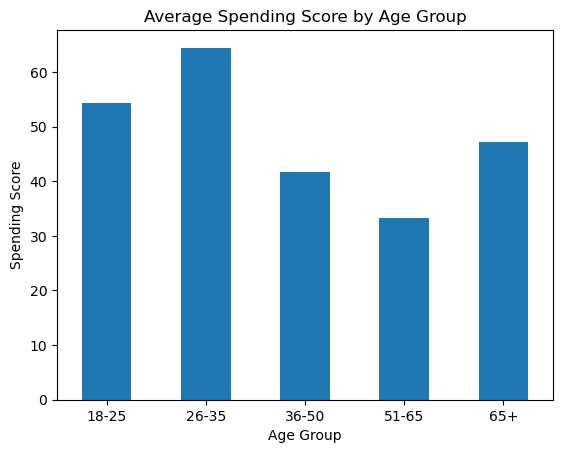

<Figure size 640x480 with 0 Axes>

In [41]:
#  Bar Chart (Age Group vs Spending)

import matplotlib.pyplot as plt

df.groupby('Age Group')['Spending Score (1-100)'].mean().plot(kind='bar')

plt.title('Average Spending Score by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Spending Score')
plt.xticks(rotation=0)
plt.show()
plt.savefig('Age vs Spending')

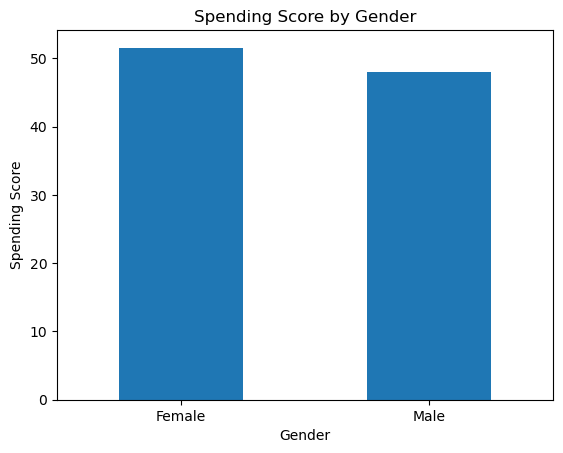

<Figure size 640x480 with 0 Axes>

In [42]:
# Gender Comparison

df.groupby('Gender')['Spending Score (1-100)'].mean().plot(kind='bar')

plt.title('Spending Score by Gender')
plt.ylabel('Spending Score')
plt.xticks(rotation=0)
plt.show()
plt.savefig('Gender vs Spending')

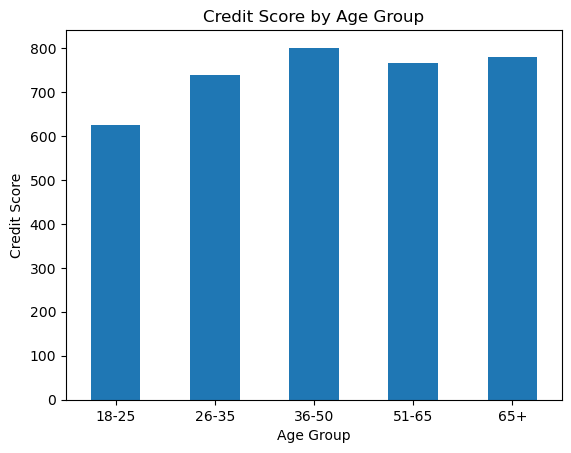

In [37]:
# Credit Score by Age Group

df.groupby('Age Group')['Credit Score'].mean().plot(kind='bar')

plt.title('Credit Score by Age Group')
plt.ylabel('Credit Score')
plt.xticks(rotation=0)
plt.show()

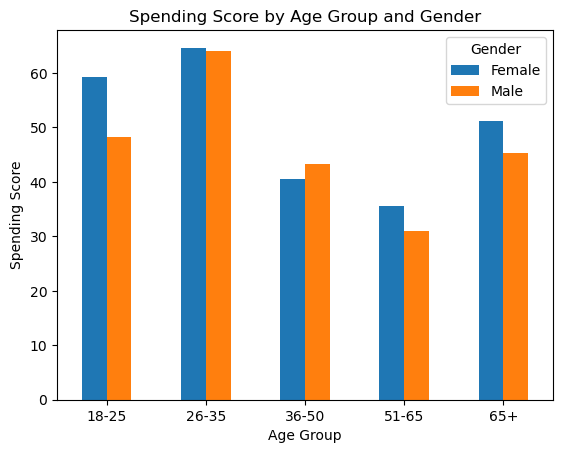

<Figure size 640x480 with 0 Axes>

In [43]:
# combined view

df.groupby(['Age Group', 'Gender'])['Spending Score (1-100)']\
  .mean().unstack().plot(kind='bar')

plt.title('Spending Score by Age Group and Gender')
plt.ylabel('Spending Score')
plt.xticks(rotation=0)
plt.show()
plt.savefig('Combined (Age + Gender)')